In [1]:
import pandas as pd
import numpy as np

In [2]:
fold0 = pd.read_csv("/scratch1/smaruj/genomic_insertion_loci/AkitaV2_cross_validation/fold0_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]
fold0["target"] = [-0.5 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv("/scratch1/smaruj/genomic_insertion_loci/AkitaV2_cross_validation/fold1_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]
fold1["target"] = [-0.5 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv("/scratch1/smaruj/genomic_insertion_loci/AkitaV2_cross_validation/fold2_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]
fold2["target"] = [-0.5 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [7]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'URQ_mean', 'URQ_AkitaV2_mean',
       'cross_valid_PearsonR', 'target'],
      dtype='object')

In [8]:
import matplotlib.pyplot as plt

In [9]:
from scipy.stats import pearsonr

r, pval = pearsonr(df["URQ_mean"], df["URQ_AkitaV2_mean"])
print(f"Pearson R = {r:.4f}, p-value = {pval:.2e}")

Pearson R = 0.8846, p-value = 1.55e-55


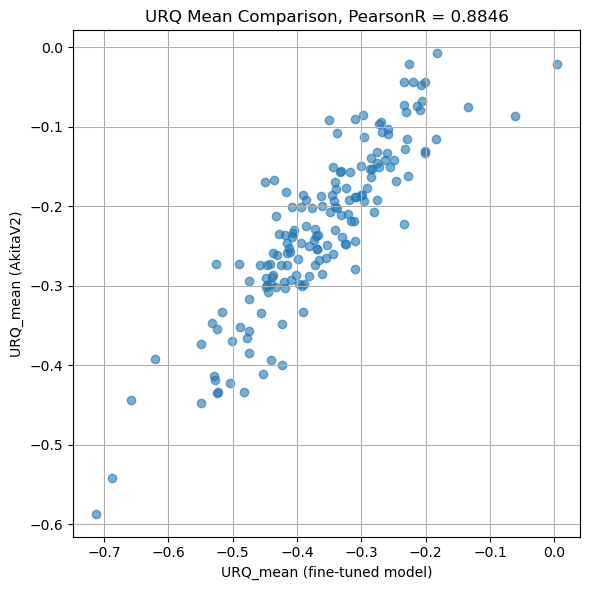

In [10]:

plt.figure(figsize=(6, 6))
plt.scatter(df["URQ_mean"], df["URQ_AkitaV2_mean"], alpha=0.6)
plt.xlabel("URQ_mean (fine-tuned model)")
plt.ylabel("URQ_mean (AkitaV2)")
plt.title(f"URQ Mean Comparison, PearsonR = {r:.4f}")
plt.grid(True)
plt.tight_layout()
plt.show()

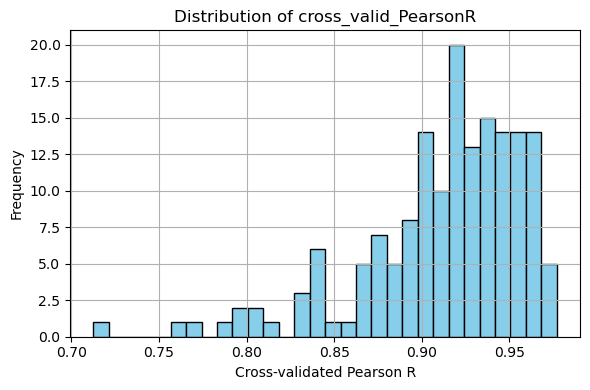

In [11]:
plt.figure(figsize=(6, 4))
plt.hist(df["cross_valid_PearsonR"], bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Cross-validated Pearson R")
plt.ylabel("Frequency")
plt.title("Distribution of cross_valid_PearsonR")
plt.grid(True)
plt.tight_layout()
plt.show()